# 银行客户流失分析
先导入写好的模块的包

In [ ]:
import sys
from pathlib import Path

# 获取当前 Notebook 所在目录（替代 __file__）
notebook_dir = Path.cwd()
# 项目根目录（假设 notebook 在项目根目录下，src 也在根目录）
project_root = notebook_dir
# 把 src 目录加入 Python 搜索路径
sys.path.append(str(project_root / "src"))

from bank_patron_losing import *
import numpy as np
import pandas as pd
import joblib

## 1. 数据预处理

使用新的预处理流程，自动完成：
- 类别编码
- 特征标准化/离散化
- 类别平衡
- 数据集划分

In [2]:
from bank_patron_losing import create_train_test_data
import numpy as np

# 创建标准化数据（SVM 和神经网络用）
print("创建标准化数据...")
preprocessor, X_train, X_test, y_train, y_test = create_train_test_data(
    "./dataset/Churn-Modelling-0-original.csv",
    output_dir="./dataset/scaled",
    discretize=False,  # False=标准化
    random_state=10
)

创建标准化数据...
数据已保存到 ./dataset/scaled/
训练集形状：(3259, 10), 测试集形状：(815, 10)
类别分布 - 训练集：[1630 1629], 测试集：[407 408]


## 2. 训练决策树

In [3]:
from bank_patron_losing import train_decision_tree

dt_model, dt_score = train_decision_tree(
    feature_train=X_train, target_train=y_train,
    feature_test=X_test, target_test=y_test
)
print(f"决策树准确率：{dt_score:.4f}")

模型已保存到 ./model/dt_model.pkl
决策树准确率：0.7448
决策树准确率：0.7448


### 2.1 绘制 ROC 曲线

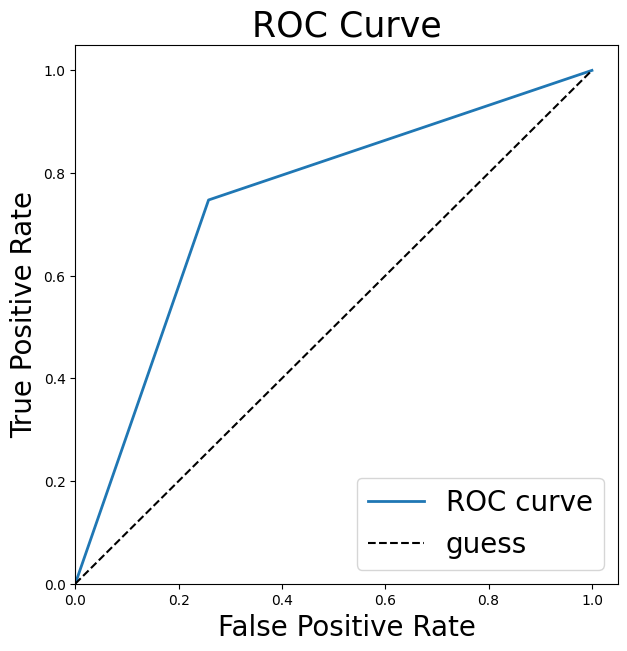

In [4]:
from bank_patron_losing import draw_roc_curve, draw_confusion_matrix, fold_cross_validation

# 保存预测结果
predict_results = np.load('./dataset/predict_results.npy')
draw_roc_curve(y_test, predict_results)

### 2.2 绘制混淆矩阵

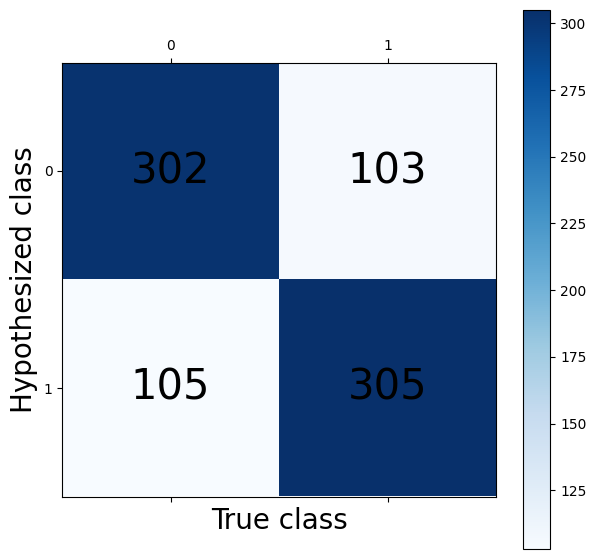

In [5]:
draw_confusion_matrix(y_test, predict_results)

### 2.3 K 折交叉验证

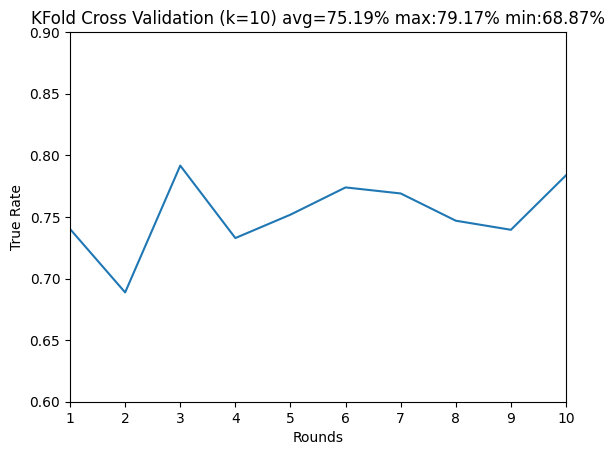

In [6]:
# 加载完整数据
feature = np.load('./dataset/scaled/feature.npy')
target = np.load('./dataset/scaled/target.npy')

fold_cross_validation(feature, target, dt_model, n_splits=10)

## 3. 训练 SVM

In [7]:
from bank_patron_losing import train_svm

svm_model, svm_score = train_svm(
    feature_train=X_train, target_train=y_train,
    feature_test=X_test, target_test=y_test
)
print(f"SVM 准确率：{svm_score:.4f}")

SVM 准确率：0.7374
SVM 准确率：0.7374


### 3.1 SVM 混淆矩阵

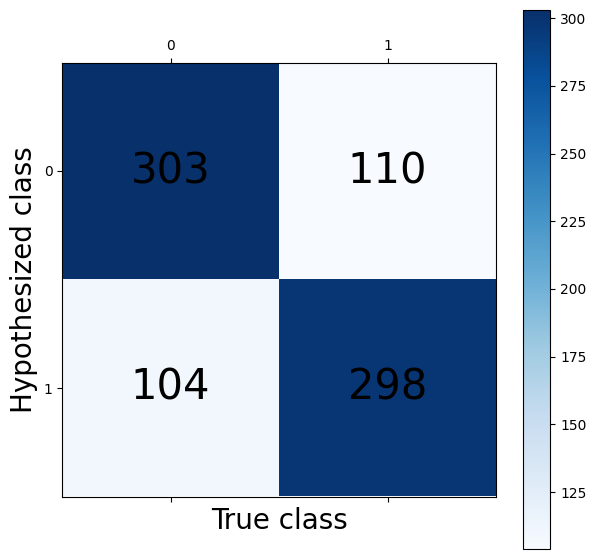

In [8]:
predict_results_svm = np.load('./dataset/predict_results_svm.npy')
draw_confusion_matrix(y_test, predict_results_svm)

## 4. 训练神经网络

In [9]:
from bank_patron_losing import train_neural_network

mlp_model, mlp_score = train_neural_network(
    feature_train=X_train, target_train=y_train,
    feature_test=X_test, target_test=y_test
)
print(f"神经网络准确率：{mlp_score:.4f}")

神经网络准确率：0.7276
神经网络准确率：0.7276


### 4.1 神经网络混淆矩阵

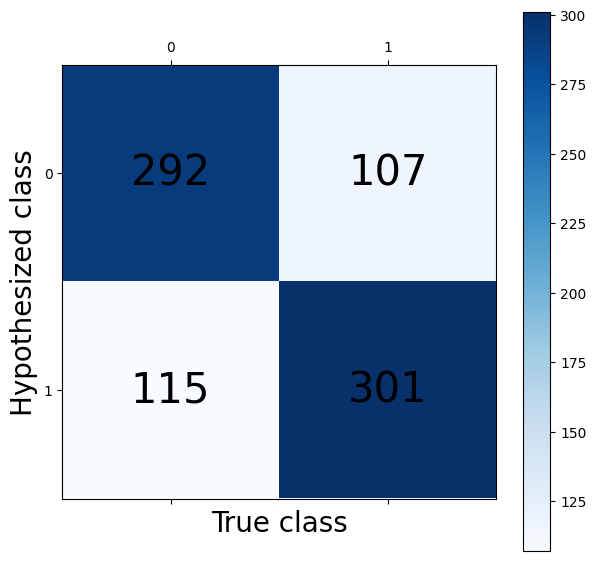

In [10]:
predict_results_mlp = np.load('./dataset/predict_results_mlp.npy')
draw_confusion_matrix(y_test, predict_results_mlp)

## 5. 模型性能对比

In [11]:
print("=" * 40)
print("模型性能对比")
print("=" * 40)
print(f"决策树准确率：    {dt_score:.4f}")
print(f"SVM 准确率：       {svm_score:.4f}")
print(f"神经网络准确率：  {mlp_score:.4f}")
print("=" * 40)

模型性能对比
决策树准确率：    0.7448
SVM 准确率：       0.7374
神经网络准确率：  0.7276
